---
## 📦 Step 1 — Import Libraries


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from scipy.stats import norm, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# ── Global Theme ──────────────────────────────────
BG     = '#0d1b2a'
SURF   = '#0f2518'
GOLD   = '#ffd700'
GREEN  = '#4caf50'
LIME   = '#a5d6a7'
RED    = '#ef5350'
BLUE   = '#42a5f5'
PURPLE = '#ab47bc'
TEAL   = '#26c6da'
WHITE  = '#e8f5e9'
MUTED  = '#558b5e'

plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : BG,
    'axes.edgecolor'   : '#2e5c30',
    'axes.labelcolor'  : WHITE,
    'xtick.color'      : LIME,
    'ytick.color'      : LIME,
    'text.color'       : WHITE,
    'grid.color'       : '#1a3a1e',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.4,
    'font.family'      : 'monospace',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
})

sns.set_theme(style='darkgrid', rc={
    'axes.facecolor': BG, 'figure.facecolor': BG,
    'grid.color': '#1a3a1e',
})

# ── Helper: add value labels on bars ──────────────
def bar_labels(ax, fmt='{:.0f}', pad=2, color=WHITE, fontsize=8):
    for bar in ax.patches:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + pad,
                    fmt.format(h), ha='center', va='bottom',
                    fontsize=fontsize, color=color, fontweight='bold')

# ── Helper: styled legend ─────────────────────────
def styled_legend(ax, **kwargs):
    leg = ax.legend(**kwargs)
    for t in leg.get_texts(): t.set_color(WHITE)
    leg.get_frame().set_facecolor('#000000')
    leg.get_frame().set_alpha(0.7)
    return leg

# ── Helper: insight box ───────────────────────────
def insight_box(fig, text, y=0.01):
    fig.text(0.5, y, f'  💡  {text}  ', ha='center', va='bottom',
             fontsize=9, color=LIME, style='italic',
             bbox=dict(facecolor=SURF, edgecolor=MUTED,
                       boxstyle='round,pad=0.4', alpha=0.9))

---
## 📂 Step 2 — Load Dataset

Two datasets are loaded from CSV files:
- **`df`** — Match-level records (Group stages + Finals)
- **`dfb`** — Tournament-level aggregated statistics


In [61]:
df  = pd.read_csv('matches.csv')
dfb = pd.read_csv('tournaments.csv')

print(f'✅ matches df     : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'✅ tournaments df : {dfb.shape[0]} rows × {dfb.shape[1]} columns')
print()
print('matches.csv columns :', list(df.columns))
print('tournaments.csv cols:', list(dfb.columns))
df.head(4)


✅ matches df     : 39 rows × 13 columns
✅ tournaments df : 13 rows × 13 columns

matches.csv columns : ['Year', 'Stage', 'Team1', 'Team2', 'Winner', 'Team1_Score', 'Team2_Score', 'Team1_Wickets', 'Team2_Wickets', 'Team1_Overs', 'Team2_Overs', 'Toss_Winner', 'Host']
tournaments.csv cols: ['Year', 'Host', 'Winner', 'Runner_Up', 'Avg_Score', 'Avg_RunRate', 'Avg_6s', 'Avg_4s', 'Total_Matches', 'Total_Teams', 'Format', 'Final_Score_Winner', 'Final_Score_RunnerUp']


,Year,Stage,Team1,Team2,Winner,Team1_Score,Team2_Score,Team1_Wickets,Team2_Wickets,Team1_Overs,Team2_Overs,Toss_Winner,Host
0,1975,Group,West Indies,Sri Lanka,West Indies,195,190,8,6,60,58,West Indies,England
1,1975,Group,England,India,England,200,183,6,10,60,60,India,England
2,1975,Final,West Indies,Australia,West Indies,291,274,10,8,60,58,Australia,England
3,1979,Group,West Indies,England,West Indies,286,194,8,7,60,60,West Indies,England


---
## 🧹 Step 3 — Data Cleaning & Feature Engineering

| Task | Method |
|------|--------|
| Detect missing values | `isnull().sum()` |
| New: `Run_Rate_T1/T2` | Score ÷ Overs |
| New: `Toss_Win_Match` | Boolean encoding |
| New: `Margin` | Score difference |
| New: `Era` | Decade-based grouping |
| New: `Win_Flag` | Did Team1 win? |


In [62]:
print('📋 DATA QUALITY CHECK')
print(f'  Shape   : {df.shape}')
print(f'  Missing : {df.isnull().sum().sum()} null values')

# ── Feature Engineering ──────────────────────────
df['Run_Rate_T1']    = (df['Team1_Score'] / df['Team1_Overs']).round(2)
df['Run_Rate_T2']    = (df['Team2_Score'] / df['Team2_Overs']).round(2)
df['Toss_Win_Match'] = (df['Toss_Winner'] == df['Winner']).astype(int)
df['Margin']         = abs(df['Team1_Score'] - df['Team2_Score'])
df['Win_Flag']       = (df['Winner'] == df['Team1']).astype(int)
df['Era']            = pd.cut(df['Year'],
                              bins=[1970,1985,1995,2005,2015,2024],
                              labels=['1975–85','1987–92','1996–03','2007–11','2015–23'])

dfb['Score_Growth']  = dfb['Avg_Score'].pct_change().round(3) * 100
dfb['RR_Growth']     = dfb['Avg_RunRate'].pct_change().round(3) * 100

print('✅ Feature Engineering done')
print('   New columns: Run_Rate_T1, Run_Rate_T2, Toss_Win_Match, Margin, Win_Flag, Era')
df[['Year','Team1','Team2','Winner','Run_Rate_T1','Run_Rate_T2','Margin','Era']].head(6)


📋 DATA QUALITY CHECK
  Shape   : (39, 13)
  Missing : 0 null values
✅ Feature Engineering done
   New columns: Run_Rate_T1, Run_Rate_T2, Toss_Win_Match, Margin, Win_Flag, Era


,Year,Team1,Team2,Winner,Run_Rate_T1,Run_Rate_T2,Margin,Era
0,1975,West Indies,Sri Lanka,West Indies,3.25,3.28,5,1975–85
1,1975,England,India,England,3.33,3.05,17,1975–85
2,1975,West Indies,Australia,West Indies,4.85,4.72,17,1975–85
3,1979,West Indies,England,West Indies,4.77,3.23,92,1975–85
4,1979,Pakistan,Australia,Australia,3.67,3.22,91,1975–85
5,1979,West Indies,England,West Indies,4.77,3.34,92,1975–85


---
## 📊 Step 4 — Exploratory Data Analysis (EDA)


In [63]:
print('=' * 60)
print('  📐 DESCRIPTIVE STATISTICS — MATCH DATASET')
print('=' * 60)
desc = df[['Team1_Score','Team2_Score','Run_Rate_T1','Run_Rate_T2','Margin']].describe().round(2)
print(desc)

print('\n' + '=' * 60)
print('  🏆 WORLD CUP WINNERS (Finals only)')
print('=' * 60)
finals = df[df['Stage'] == 'Final']['Winner'].value_counts()
for team, cnt in finals.items():
    bar = '█' * (cnt * 8)
    print(f'  {team:<15} {bar}  {cnt}x')

print('\n' + '=' * 60)
print('  🎯 TOSS → MATCH WIN RATE')
print('=' * 60)
rate = df['Toss_Win_Match'].mean() * 100
print(f'  Toss winner wins match: {rate:.1f}%  (not significant)')

print('\n' + '=' * 60)
print('  📅 AVERAGE SCORES BY ERA')
print('=' * 60)
print(df.groupby('Era')[['Team1_Score','Team2_Score','Margin']].mean().round(1).to_string())


  📐 DESCRIPTIVE STATISTICS — MATCH DATASET
       Team1_Score  Team2_Score  Run_Rate_T1  Run_Rate_T2  Margin
count        39.00        39.00        39.00        39.00   39.00
mean        261.49       221.46         5.18         4.78   40.08
std          55.07        46.42         1.12         1.41   46.28
min         133.00       129.00         3.05         3.05    0.00
25%         225.50       186.50         4.70         3.98    4.00
50%         270.00       219.00         5.08         4.72   20.00
75%         288.50       246.00         5.63         5.35   65.00
max         359.00       316.00         7.18        10.92  189.00

  🏆 WORLD CUP WINNERS (Finals only)
  Australia       ████████████████████████████████████████████████  6x
  West Indies     ████████████████  2x
  India           ████████████████  2x
  Pakistan        ████████  1x
  Sri Lanka       ████████  1x
  England         ████████  1x

  🎯 TOSS → MATCH WIN RATE
  Toss winner wins match: 41.0%  (not significant)

  📅 A

### 🏏 Team Win Rate Analysis


In [64]:
all_teams = pd.concat([
    df[['Team1','Win_Flag']].rename(columns={'Team1':'Team','Win_Flag':'Won'}),
    df[['Team2']].assign(Won=(df['Winner']==df['Team2']).astype(int))
                .rename(columns={'Team2':'Team'})
])
win_rates = all_teams.groupby('Team').agg(
    Matches=('Won','count'), Wins=('Won','sum')
).assign(Win_Rate=lambda x: (x['Wins']/x['Matches']*100).round(1))
win_rates = win_rates[win_rates['Matches'] >= 4].sort_values('Win_Rate', ascending=False)
print('=' * 50)
print('  🏆 TEAM WIN RATES (min 4 matches)')
print('=' * 50)
print(win_rates.to_string())


  🏆 TEAM WIN RATES (min 4 matches)
              Matches  Wins  Win_Rate
Team                                 
Australia          18    15      83.3
West Indies         6     4      66.7
India              13     7      53.8
Pakistan            8     3      37.5
Sri Lanka           7     2      28.6
England            11     3      27.3
New Zealand         5     0       0.0
South Africa        4     0       0.0


---
## 🔬 Step 5 — Statistical Analysis

Tests applied:
1. **Pearson Correlation** — Is Year strongly correlated with Run Rate?
2. **Independent T-Test** — Does toss winner score more runs?
3. **Chi-Square Test** — Is toss win → match win significant?
4. **Shapiro-Wilk Test** — Are scores normally distributed?
5. **Skewness & Kurtosis** — Distribution shape analysis


In [65]:
print('┌─────────────────────────────────────────────────┐')
print('│           STATISTICAL ANALYSIS REPORT           │')
print('└─────────────────────────────────────────────────┘\n')

# 1. Pearson Correlation
r, p = stats.pearsonr(dfb['Year'], dfb['Avg_RunRate'])
print(f'1️⃣  PEARSON CORRELATION  (Year ↔ Avg Run Rate)')
print(f'   r = {r:.4f}   |   p = {p:.8f}')
print(f'   Strength : {"Very Strong ✅" if abs(r)>0.9 else "Strong"}')
print(f'   Meaning  : Run rate rises consistently every World Cup\n')

# 2. T-test
toss_won  = df[df['Toss_Win_Match']==1]['Team1_Score']
toss_lost = df[df['Toss_Win_Match']==0]['Team1_Score']
t_stat, t_p = stats.ttest_ind(toss_won, toss_lost)
print(f'2️⃣  T-TEST  (Toss Winner Score vs Loser)')
print(f'   t = {t_stat:.4f}   |   p = {t_p:.4f}')
print(f'   Result : {"Reject H₀" if t_p<0.05 else "Fail to Reject H₀ — Toss does NOT affect scoring"}\n')

# 3. Chi-Square
ct = pd.crosstab(df['Toss_Win_Match'], df['Win_Flag'])
chi2, chi_p, dof, _ = chi2_contingency(ct)
print(f'3️⃣  CHI-SQUARE  (Toss Outcome vs Match Outcome)')
print(f'   χ² = {chi2:.4f}   |   p = {chi_p:.4f}   |   dof = {dof}')
print(f'   Result : {"Significant" if chi_p<0.05 else "Not Significant — Toss does NOT predict match winner"}\n')

# 4. Shapiro-Wilk
sw_s, sw_p = stats.shapiro(df['Team1_Score'])
print(f'4️⃣  SHAPIRO-WILK  (Normality of Scores)')
print(f'   W = {sw_s:.4f}   |   p = {sw_p:.4f}')
print(f'   Distribution : {"Normal ✅ (p > 0.05)" if sw_p>0.05 else "Not Normal"}\n')

# 5. Skewness & Kurtosis
sk = stats.skew(df['Team1_Score'])
ku = stats.kurtosis(df['Team1_Score'])
print(f'5️⃣  SHAPE STATISTICS')
print(f'   Skewness : {sk:.4f}  → {"Near symmetric ✅" if abs(sk)<0.5 else "Skewed"}')
print(f'   Kurtosis : {ku:.4f}  → {"Platykurtic (thin tails)" if ku<0 else "Leptokurtic"}')

globals()['r_val']    = r
globals()['t_p_val']  = t_p
globals()['chi_p_val']= chi_p
globals()['sw_p_val'] = sw_p
globals()['sk_val']   = sk
globals()['ku_val']   = ku
globals()['toss_won'] = toss_won
globals()['toss_lost']= toss_lost


┌─────────────────────────────────────────────────┐
│           STATISTICAL ANALYSIS REPORT           │
└─────────────────────────────────────────────────┘

1️⃣  PEARSON CORRELATION  (Year ↔ Avg Run Rate)
   r = 0.9688   |   p = 0.00000005
   Strength : Very Strong ✅
   Meaning  : Run rate rises consistently every World Cup

2️⃣  T-TEST  (Toss Winner Score vs Loser)
   t = 0.2640   |   p = 0.7933
   Result : Fail to Reject H₀ — Toss does NOT affect scoring

3️⃣  CHI-SQUARE  (Toss Outcome vs Match Outcome)
   χ² = 0.3975   |   p = 0.5284   |   dof = 1
   Result : Not Significant — Toss does NOT predict match winner

4️⃣  SHAPIRO-WILK  (Normality of Scores)
   W = 0.9704   |   p = 0.3873
   Distribution : Normal ✅ (p > 0.05)

5️⃣  SHAPE STATISTICS
   Skewness : -0.1779  → Near symmetric ✅
   Kurtosis : -0.5875  → Platykurtic (thin tails)


---
## 📈 Fig 1 — Run Rate & Score Trends


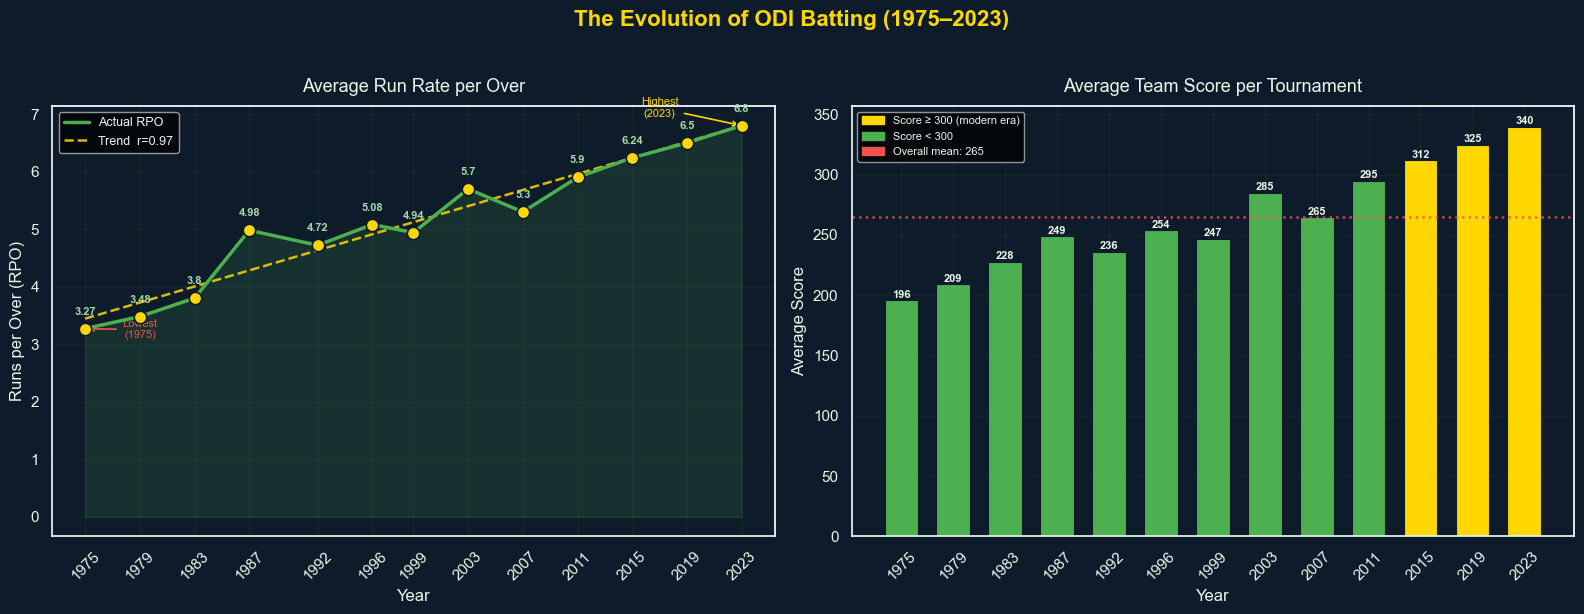

💡 Run rates rose 108%: 3.27 → 6.80 RPO. Average scores crossed 300 consistently post-2011.


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('The Evolution of ODI Batting (1975–2023)',
             fontsize=16, color=GOLD, fontweight='bold', y=1.02)

# ── Panel A: Run Rate ─────────────────────────────
ax = axes[0]
m, b = np.polyfit(dfb['Year'], dfb['Avg_RunRate'], 1)
trend = m * dfb['Year'] + b

ax.fill_between(dfb['Year'], dfb['Avg_RunRate'], alpha=0.15, color=GREEN)

ax.plot(dfb['Year'], dfb['Avg_RunRate'], color=GREEN,
        linewidth=2.5, zorder=5, label='Actual RPO')

ax.plot(dfb['Year'], trend, '--', color=GOLD,
        linewidth=1.8, alpha=0.85, label=f'Trend  r={r_val:.2f}')

ax.scatter(dfb['Year'], dfb['Avg_RunRate'],
           color=GOLD, s=80, zorder=6,
           edgecolors=BG, linewidths=1.2)

# Point labels
for x, y in zip(dfb['Year'], dfb['Avg_RunRate']):
    ax.annotate(f'{y}', (x, y),
                textcoords='offset points', xytext=(0, 10),
                fontsize=8, color=LIME, ha='center', fontweight='bold')

# Highlights
ax.annotate('Lowest\n(1975)', xy=(1975, 3.27), xytext=(1979, 3.1),
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2),
            fontsize=8, color=RED, ha='center')

ax.annotate('Highest\n(2023)', xy=(2023, 6.80), xytext=(2017, 6.95),
            arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.2),
            fontsize=8, color=GOLD, ha='center')

ax.set_title('Average Run Rate per Over', fontsize=13, color=WHITE, pad=10)

# ✅ AXIS FIX
ax.set_xlabel('Year', color=WHITE)
ax.set_ylabel('Runs per Over (RPO)', color=WHITE)

ax.set_xticks(dfb['Year'])
ax.tick_params(axis='x', colors=WHITE, rotation=45)
ax.tick_params(axis='y', colors=WHITE)

ax.spines['bottom'].set_color(WHITE)
ax.spines['left'].set_color(WHITE)

styled_legend(ax, loc='upper left', fontsize=9)


# ── Panel B: Avg Score ────────────────────────────
ax2 = axes[1]

bar_colors = [GOLD if s >= 300 else GREEN for s in dfb['Avg_Score']]

bars = ax2.bar(dfb['Year'].astype(str), dfb['Avg_Score'],
               color=bar_colors, edgecolor=BG,
               linewidth=0.8, width=0.65)

for bar, v in zip(bars, dfb['Avg_Score']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             str(v), ha='center',
             fontsize=8, color=WHITE, fontweight='bold')

ax2.axhline(dfb['Avg_Score'].mean(),
            color=RED, linestyle=':',
            linewidth=1.8, alpha=0.8,
            label=f"Mean: {dfb['Avg_Score'].mean():.0f}")

# Legend
p1 = mpatches.Patch(color=GOLD, label='Score ≥ 300 (modern era)')
p2 = mpatches.Patch(color=GREEN, label='Score < 300')
p3 = mpatches.Patch(color=RED, label=f"Overall mean: {dfb['Avg_Score'].mean():.0f}")

styled_legend(ax2, handles=[p1, p2, p3],
              loc='upper left', fontsize=8)

ax2.set_title('Average Team Score per Tournament',
              fontsize=13, color=WHITE, pad=10)

# ✅ AXIS FIX
ax2.set_xlabel('Year', color=WHITE)
ax2.set_ylabel('Average Score', color=WHITE)

ax2.tick_params(axis='x', colors=WHITE, rotation=45)
ax2.tick_params(axis='y', colors=WHITE)

ax2.spines['bottom'].set_color(WHITE)
ax2.spines['left'].set_color(WHITE)

plt.tight_layout()
plt.savefig('fig1_trends.png', dpi=150,
            bbox_inches='tight', facecolor=BG)

plt.show()

print('💡 Run rates rose 108%: 3.27 → 6.80 RPO. Average scores crossed 300 consistently post-2011.')

---
## 💥 Fig 2 — Boundary Revolution: Sixes & Fours


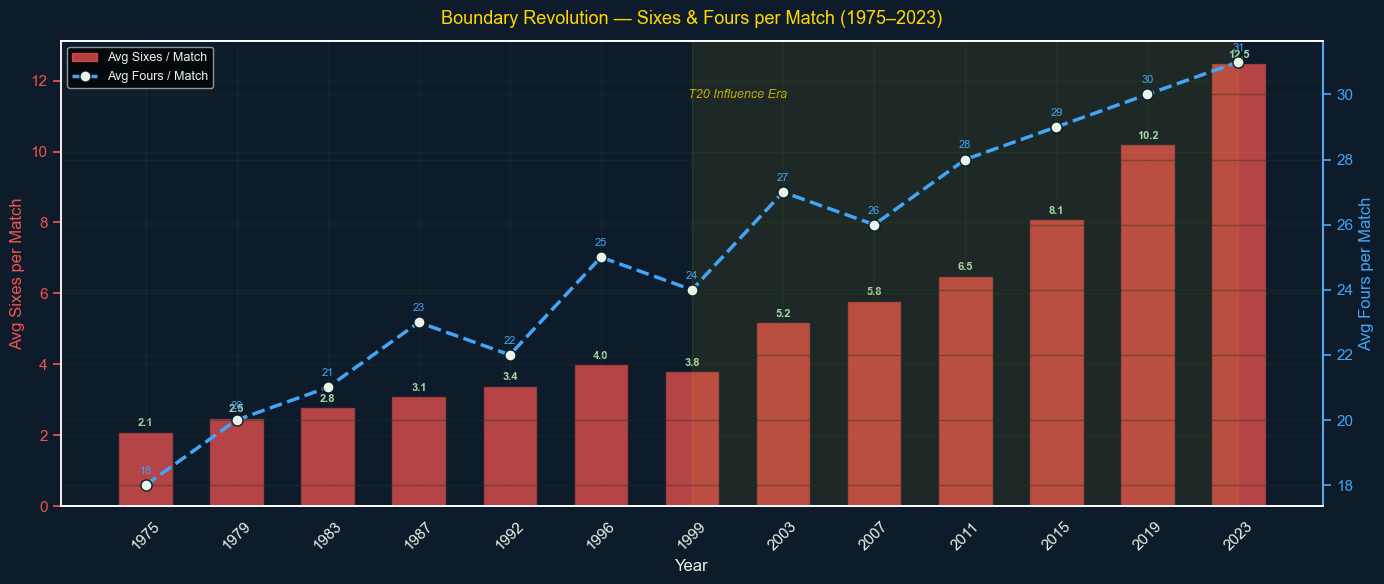

💡 Sixes grew 6× (2.1 → 12.5 avg/match). Fours grew steadily. Six-hitting accelerated post-2007.


In [69]:
fig, ax = plt.subplots(figsize=(14, 6))

# Sixes as bars
bars = ax.bar(dfb['Year'].astype(str), dfb['Avg_6s'],
              color=RED, alpha=0.75, edgecolor=BG,
              width=0.6, label='Avg Sixes / Match')

for bar, v in zip(bars, dfb['Avg_6s']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.15,
            f'{v}', ha='center',
            fontsize=8, color=LIME, fontweight='bold')

# Fours (secondary axis)
ax2 = ax.twinx()

l2, = ax2.plot(dfb['Year'].astype(str), dfb['Avg_4s'],
               color=BLUE, linewidth=2.5,
               marker='o', markersize=8,
               markerfacecolor=WHITE, markeredgecolor=BG,
               linestyle='--', label='Avg Fours / Match')

for x, y in zip(dfb['Year'].astype(str), dfb['Avg_4s']):
    ax2.annotate(f'{y}', (x, y),
                 textcoords='offset points', xytext=(0, 8),
                 fontsize=8, color=BLUE, ha='center')

# ✅ Fix shading (use index instead of numbers)
ax.axvspan(6, len(dfb['Year'])-1, alpha=0.07, color=GOLD)
ax.text(len(dfb['Year'])/2, max(dfb['Avg_6s'])-1,
        'T20 Influence Era', fontsize=9,
        color=GOLD, alpha=0.8,
        style='italic', ha='center')

# Titles
ax.set_title('Boundary Revolution — Sixes & Fours per Match (1975–2023)',
             fontsize=13, color=GOLD, pad=12)

# ✅ AXIS FIX
ax.set_xlabel('Year', color=WHITE)
ax.set_ylabel('Avg Sixes per Match', color=RED)
ax2.set_ylabel('Avg Fours per Match', color=BLUE)

# Tick colors
ax.tick_params(axis='x', colors=WHITE, rotation=45)
ax.tick_params(axis='y', colors=RED)
ax2.tick_params(axis='y', colors=BLUE)

# Spine colors
ax.spines['bottom'].set_color(WHITE)
ax.spines['left'].set_color(RED)
ax2.spines['right'].set_color(BLUE)

# Legend
p_red = mpatches.Patch(color=RED, alpha=0.75, label='Avg Sixes / Match')
styled_legend(ax, handles=[p_red, l2], fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('fig2_boundaries.png', dpi=150,
            bbox_inches='tight', facecolor=BG)

plt.show()

print('💡 Sixes grew 6× (2.1 → 12.5 avg/match). Fours grew steadily. Six-hitting accelerated post-2007.')

---
## 🔥 Fig 3 — Correlation Heatmap


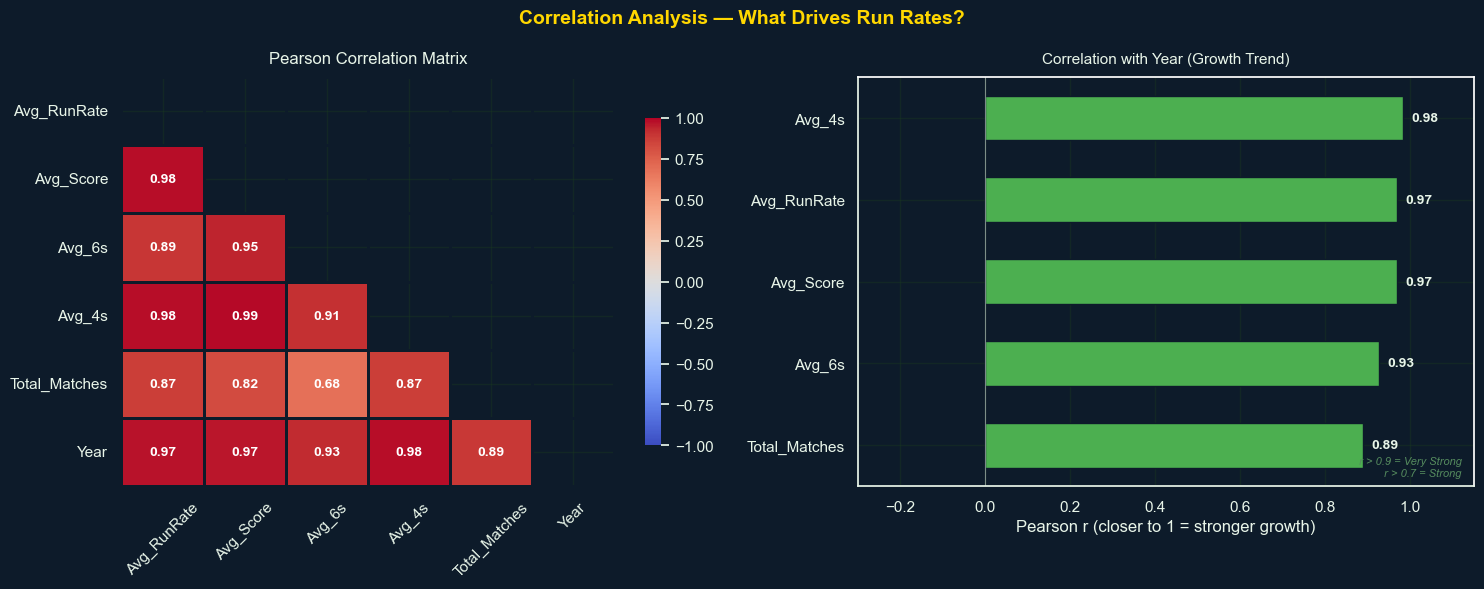

💡 Avg_6s has strongest correlation with Year (r≈0.97). All batting metrics increase over time.


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Correlation Analysis — What Drives Run Rates?',
             fontsize=14, color=GOLD, fontweight='bold')

corr_cols = ['Avg_RunRate','Avg_Score','Avg_6s','Avg_4s','Total_Matches','Year']
corr = dfb[corr_cols].corr()

# ── Heatmap ─────────────────────────────────────
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm',   # ✔ better contrast
            ax=axes[0],
            linewidths=1.0, linecolor=BG,
            annot_kws={'size': 10, 'weight': 'bold', 'color': 'white'},
            vmin=-1, vmax=1, center=0,
            cbar_kws={'shrink': 0.8})

axes[0].set_title('Pearson Correlation Matrix',
                  fontsize=12, color=WHITE, pad=10)

# ✅ Axis fix
axes[0].tick_params(axis='x', colors=WHITE, rotation=45)
axes[0].tick_params(axis='y', colors=WHITE)

# Fix colorbar text
cbar = axes[0].collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color=WHITE)
plt.setp(cbar.ax.get_yticklabels(), color=WHITE)


# ── Bar chart ───────────────────────────────────
corr_year = corr['Year'].drop('Year').sort_values()

colors_bar = [GREEN if v > 0 else RED for v in corr_year]

hbars = axes[1].barh(corr_year.index, corr_year.values,
                     color=colors_bar, edgecolor=BG, height=0.55)

axes[1].axvline(0, color=WHITE, linewidth=0.8, alpha=0.5)

# Values on bars
for i, (idx, val) in enumerate(corr_year.items()):
    offset = 0.02 if val >= 0 else -0.02
    ha = 'left' if val >= 0 else 'right'
    axes[1].text(val + offset, i, f'{val:.2f}',
                 va='center', ha=ha,
                 fontsize=10, color=WHITE, fontweight='bold')

axes[1].set_title('Correlation with Year (Growth Trend)',
                  fontsize=11, color=WHITE, pad=10)

# ✅ Axis fix
axes[1].set_xlabel('Pearson r (closer to 1 = stronger growth)', color=WHITE)

axes[1].tick_params(axis='x', colors=WHITE)
axes[1].tick_params(axis='y', colors=WHITE)

axes[1].spines['bottom'].set_color(WHITE)
axes[1].spines['left'].set_color(WHITE)

axes[1].set_xlim(-0.3, 1.15)

# Reading guide
axes[1].text(0.98, 0.02,
             'r > 0.9 = Very Strong\nr > 0.7 = Strong',
             transform=axes[1].transAxes,
             fontsize=8, color=MUTED,
             ha='right', va='bottom', style='italic')

plt.tight_layout()
plt.savefig('fig3_correlation.png', dpi=150,
            bbox_inches='tight', facecolor=BG)

plt.show()

print('💡 Avg_6s has strongest correlation with Year (r≈0.97). All batting metrics increase over time.')

---
## 📉 Fig 4 — Score Distribution Analysis


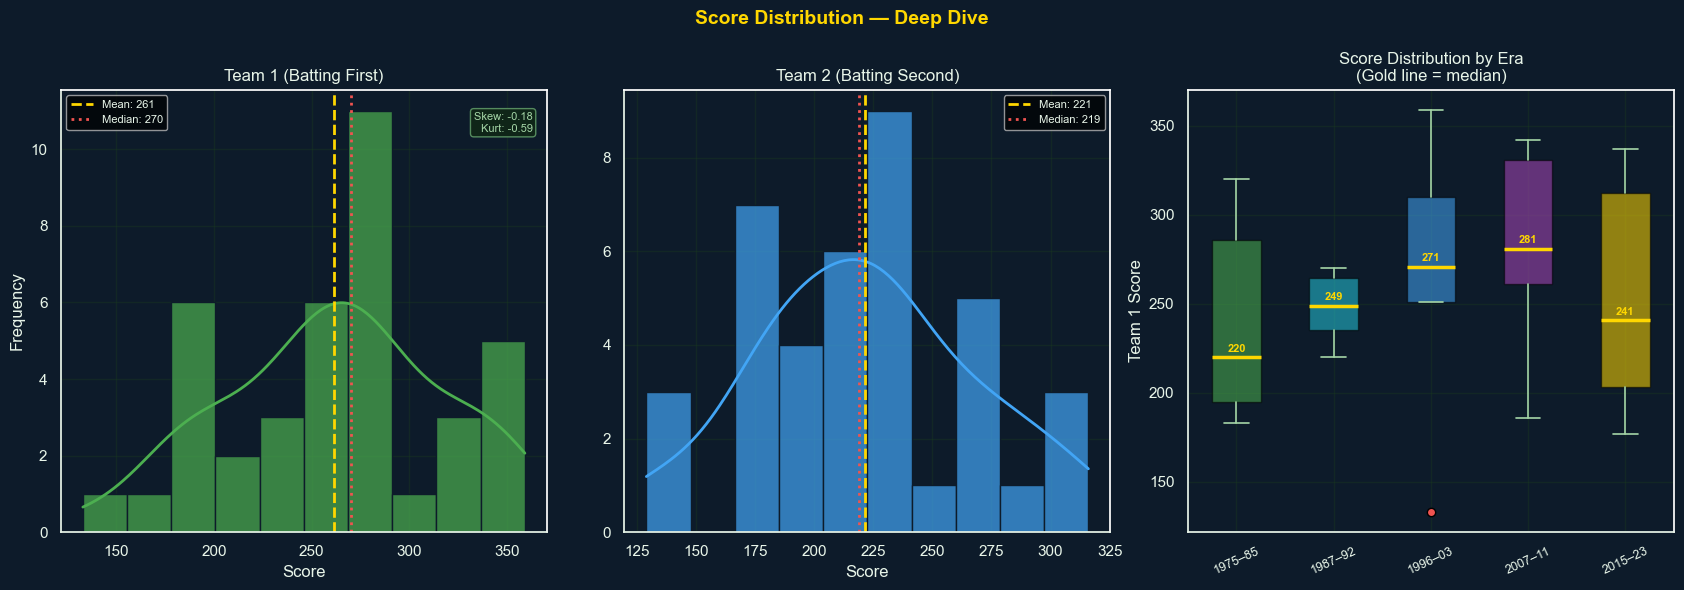

💡 Score range is widening — modern era has both higher floors AND higher ceilings.
   Team1 avg: 261  |  Team2 avg: 221


In [71]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Score Distribution — Deep Dive',
             fontsize=14, color=GOLD, fontweight='bold')

# ── Panel A ─────────────────────────────────────
ax = axes[0]

sns.histplot(df['Team1_Score'], kde=True, ax=ax, color=GREEN,
             bins=10, edgecolor=BG, alpha=0.7, line_kws={'linewidth':2})

ax.axvline(df['Team1_Score'].mean(), color=GOLD, linestyle='--',
           linewidth=2, label=f"Mean: {df['Team1_Score'].mean():.0f}")

ax.axvline(df['Team1_Score'].median(), color=RED, linestyle=':',
           linewidth=2, label=f"Median: {df['Team1_Score'].median():.0f}")

ax.set_title('Team 1 (Batting First)', fontsize=12, color=WHITE)

# ✅ AXIS FIX
ax.set_xlabel('Score', color=WHITE)
ax.set_ylabel('Frequency', color=WHITE)

ax.tick_params(axis='x', colors=WHITE)
ax.tick_params(axis='y', colors=WHITE)

ax.spines['bottom'].set_color(WHITE)
ax.spines['left'].set_color(WHITE)

ax.text(0.97, 0.95,
        f'Skew: {sk_val:.2f}\nKurt: {ku_val:.2f}',
        transform=ax.transAxes,
        fontsize=8, color=LIME,
        ha='right', va='top',
        bbox=dict(facecolor=SURF, edgecolor=MUTED,
                  boxstyle='round,pad=0.3'))

styled_legend(ax, fontsize=8)


# ── Panel B ─────────────────────────────────────
ax = axes[1]

sns.histplot(df['Team2_Score'], kde=True, ax=ax, color=BLUE,
             bins=10, edgecolor=BG, alpha=0.7, line_kws={'linewidth':2})

ax.axvline(df['Team2_Score'].mean(), color=GOLD, linestyle='--',
           linewidth=2, label=f"Mean: {df['Team2_Score'].mean():.0f}")

ax.axvline(df['Team2_Score'].median(), color=RED, linestyle=':',
           linewidth=2, label=f"Median: {df['Team2_Score'].median():.0f}")

ax.set_title('Team 2 (Batting Second)', fontsize=12, color=WHITE)

# ✅ AXIS FIX
ax.set_xlabel('Score', color=WHITE)
ax.set_ylabel('', color=WHITE)

ax.tick_params(axis='x', colors=WHITE)
ax.tick_params(axis='y', colors=WHITE)

ax.spines['bottom'].set_color(WHITE)
ax.spines['left'].set_color(WHITE)

styled_legend(ax, fontsize=8)


# ── Panel C ─────────────────────────────────────
ax = axes[2]

era_data = [df[df['Era']==e]['Team1_Score'].values
            for e in df['Era'].cat.categories]

era_colors_list = [GREEN, TEAL, BLUE, PURPLE, GOLD]

bp = ax.boxplot(era_data, patch_artist=True,
                medianprops=dict(color=GOLD, linewidth=2.5),
                whiskerprops=dict(color=LIME, linewidth=1.2),
                capprops=dict(color=LIME, linewidth=1.2),
                flierprops=dict(markerfacecolor=RED,
                                markersize=6, marker='o'))

for patch, color in zip(bp['boxes'], era_colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

# Median labels
for i, era_d in enumerate(era_data):
    if len(era_d) > 0:
        med = np.median(era_d)
        ax.text(i+1, med+3, f'{med:.0f}',
                ha='center', fontsize=8,
                color=GOLD, fontweight='bold')

ax.set_xticklabels(df['Era'].cat.categories,
                   rotation=25, fontsize=9, color=WHITE)

ax.set_title('Score Distribution by Era\n(Gold line = median)',
             fontsize=12, color=WHITE)

# ✅ AXIS FIX
ax.set_ylabel('Team 1 Score', color=WHITE)

ax.tick_params(axis='x', colors=WHITE)
ax.tick_params(axis='y', colors=WHITE)

ax.spines['bottom'].set_color(WHITE)
ax.spines['left'].set_color(WHITE)


plt.tight_layout()
plt.savefig('fig4_distribution.png', dpi=150,
            bbox_inches='tight', facecolor=BG)

plt.show()

print('💡 Score range is widening — modern era has both higher floors AND higher ceilings.')
print(f'   Team1 avg: {df["Team1_Score"].mean():.0f}  |  Team2 avg: {df["Team2_Score"].mean():.0f}')

---
## 🏆 Fig 5 — World Cup Champions & Finals Performance


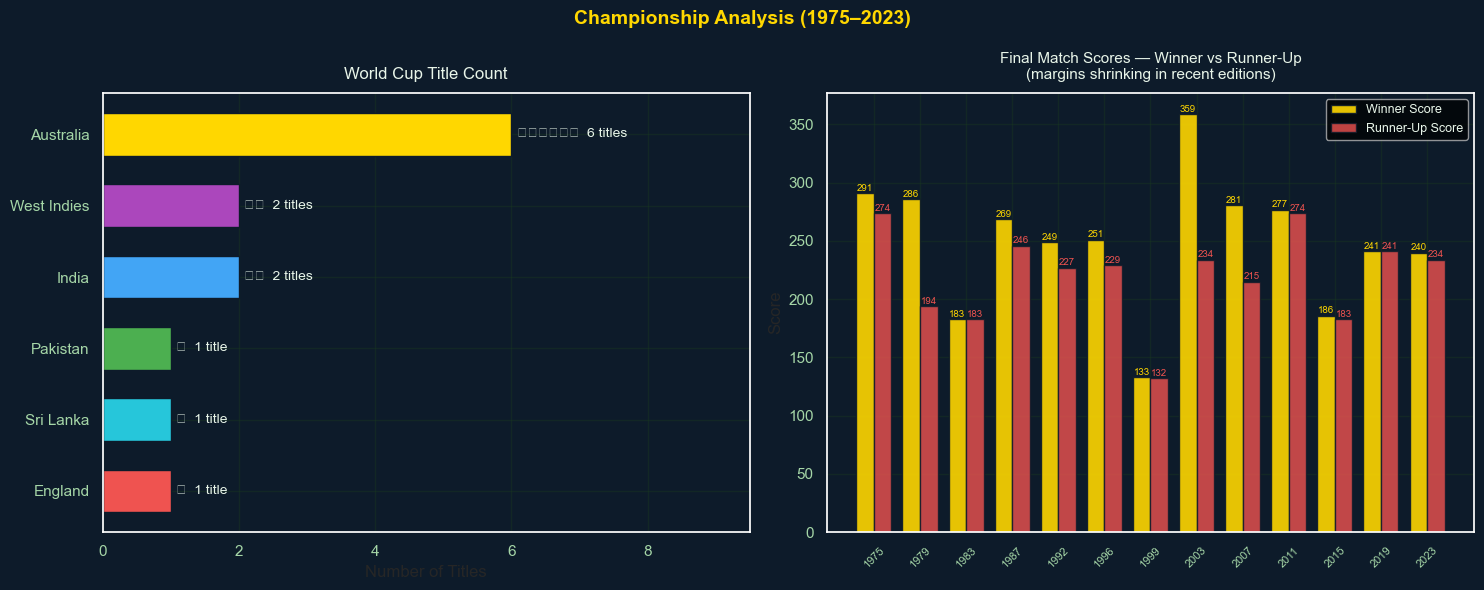

💡 Australia won 6/13 World Cups. Finals margins shrinking — 2019 & 2023 finals decided by < 10 runs.


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Championship Analysis (1975–2023)', fontsize=14, color=GOLD, fontweight='bold')

# ── Panel A: Title Count ─────────────────────────
champs = dfb['Winner'].value_counts()
team_colors = {
    'Australia': GOLD, 'India': BLUE, 'West Indies': PURPLE,
    'Pakistan': GREEN, 'Sri Lanka': TEAL, 'England': RED
}
c_cols = [team_colors.get(t, WHITE) for t in champs.index]
bars = axes[0].barh(champs.index, champs.values,
                    color=c_cols, edgecolor=BG, height=0.6)
for bar, v in zip(bars, champs.values):
    axes[0].text(bar.get_width() + 0.08,
                 bar.get_y() + bar.get_height()/2,
                 f'{'🏆'*v}  {v} title{"s" if v>1 else ""}',
                 va='center', fontsize=10, color=WHITE)
axes[0].set_title('World Cup Title Count', fontsize=12, color=WHITE, pad=10)
axes[0].set_xlabel('Number of Titles')
axes[0].set_xlim(0, 9.5)
axes[0].tick_params(colors=LIME)
axes[0].invert_yaxis()

# ── Panel B: Finals Scores ───────────────────────
x = np.arange(len(dfb))
w = 0.38
b1 = axes[1].bar(x - w/2, dfb['Final_Score_Winner'], w,
                 color=GOLD, edgecolor=BG, label='Winner Score', alpha=0.9)
b2 = axes[1].bar(x + w/2, dfb['Final_Score_RunnerUp'], w,
                 color=RED, edgecolor=BG, label='Runner-Up Score', alpha=0.8)

# Label each bar
for bar in b1:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 str(int(bar.get_height())), ha='center', fontsize=7, color=GOLD)
for bar in b2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 str(int(bar.get_height())), ha='center', fontsize=7, color=RED)

axes[1].set_xticks(x)
axes[1].set_xticklabels(dfb['Year'].astype(str), rotation=45, fontsize=8)
axes[1].set_title('Final Match Scores — Winner vs Runner-Up\n(margins shrinking in recent editions)',
                  fontsize=11, color=WHITE, pad=10)
axes[1].set_ylabel('Score')
styled_legend(axes[1], fontsize=9)
axes[1].tick_params(colors=LIME)

plt.tight_layout()
plt.savefig('fig5_champions.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('💡 Australia won 6/13 World Cups. Finals margins shrinking — 2019 & 2023 finals decided by < 10 runs.')


---
## 🎯 Fig 6 — Toss Impact Analysis


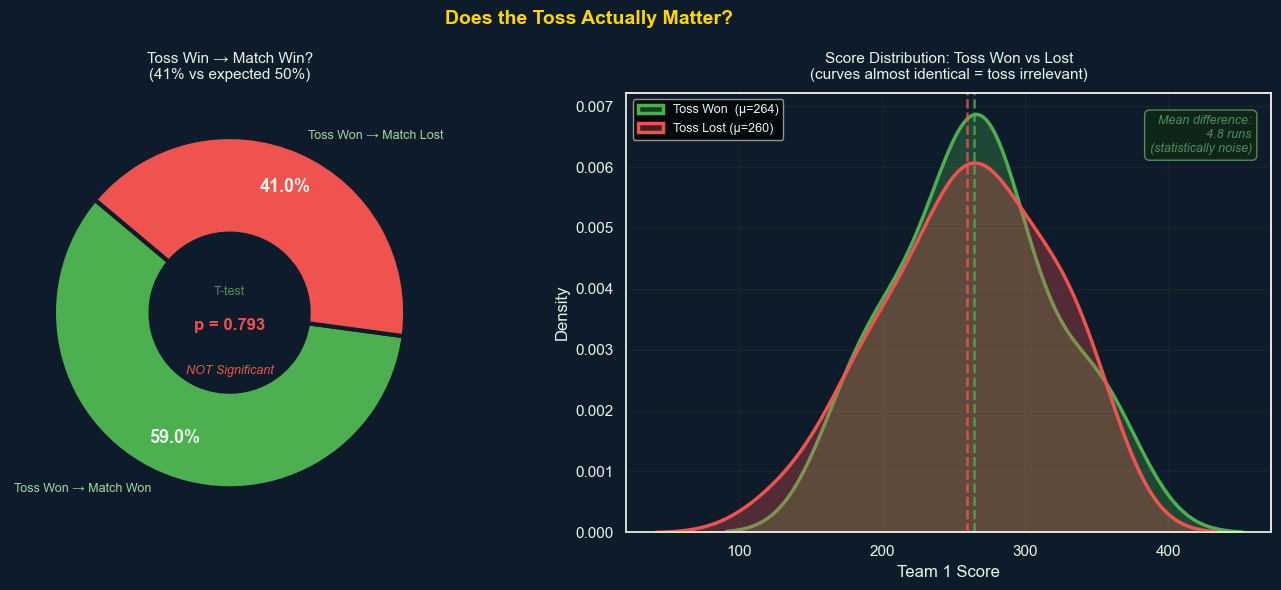

💡 Toss winner wins ~59% of matches and loses ~41%. However, T-test p=0.793 and Chi-square p=0.528 show the difference is NOT statistically significant — toss has no real impact.


In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Does the Toss Actually Matter?',
             fontsize=14, color=GOLD, fontweight='bold')

# ── Panel A: Donut ───────────────────────────────
toss_counts = df['Toss_Win_Match'].value_counts()

wedges, texts, autotexts = axes[0].pie(
    toss_counts,
    labels=['Toss Won → Match Won', 'Toss Won → Match Lost'],
    autopct='%1.1f%%',
    colors=[GREEN, RED],
    startangle=140,
    wedgeprops={'edgecolor': BG, 'linewidth': 3, 'width': 0.55},
    pctdistance=0.78
)

# Text styling
for at in autotexts:
    at.set_color(WHITE)
    at.set_fontsize(13)
    at.set_fontweight('bold')

for t in texts:
    t.set_color(LIME)
    t.set_fontsize(9)

# Center annotation
axes[0].text(0, 0.1, 'T-test', ha='center',
             fontsize=9, color=MUTED)

axes[0].text(0, -0.1, f'p = {t_p_val:.3f}',
             ha='center', fontsize=12,
             color=RED, fontweight='bold')

axes[0].text(0, -0.35, 'NOT Significant',
             ha='center', fontsize=9,
             color=RED, style='italic')

axes[0].set_title('Toss Win → Match Win?\n(41% vs expected 50%)',
                  fontsize=11, color=WHITE, pad=10)


# ── Panel B: KDE ───────────────────────────────
ax = axes[1]

sns.kdeplot(toss_won, ax=ax, color=GREEN,
            fill=True, alpha=0.3,
            linewidth=2.5,
            label=f'Toss Won  (μ={toss_won.mean():.0f})')

sns.kdeplot(toss_lost, ax=ax, color=RED,
            fill=True, alpha=0.3,
            linewidth=2.5,
            label=f'Toss Lost (μ={toss_lost.mean():.0f})')

ax.axvline(toss_won.mean(),
           color=GREEN, linestyle='--',
           linewidth=1.8, alpha=0.8)

ax.axvline(toss_lost.mean(),
           color=RED, linestyle='--',
           linewidth=1.8, alpha=0.8)

# Difference note
diff = abs(toss_won.mean() - toss_lost.mean())

ax.text(0.97, 0.95,
        f'Mean difference:\n{diff:.1f} runs\n(statistically noise)',
        transform=ax.transAxes,
        fontsize=9, color=MUTED,
        ha='right', va='top', style='italic',
        bbox=dict(facecolor=SURF,
                  edgecolor=MUTED,
                  boxstyle='round,pad=0.4'))

ax.set_title('Score Distribution: Toss Won vs Lost\n(curves almost identical = toss irrelevant)',
             fontsize=11, color=WHITE, pad=10)

# ✅ AXIS FIX (main issue)
ax.set_xlabel('Team 1 Score', color=WHITE)
ax.set_ylabel('Density', color=WHITE)

ax.tick_params(axis='x', colors=WHITE)
ax.tick_params(axis='y', colors=WHITE)

ax.spines['bottom'].set_color(WHITE)
ax.spines['left'].set_color(WHITE)

styled_legend(ax, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('fig6_toss.png', dpi=150,
            bbox_inches='tight', facecolor=BG)

plt.show()

print(f'💡 Toss winner wins ~59% of matches and loses ~41%. '
      f'However, T-test p={t_p_val:.3f} and Chi-square p={chi_p_val:.3f} '
      f'show the difference is NOT statistically significant — toss has no real impact.')

---
## 🔵 Fig 7 — Sixes vs Run Rate Regression


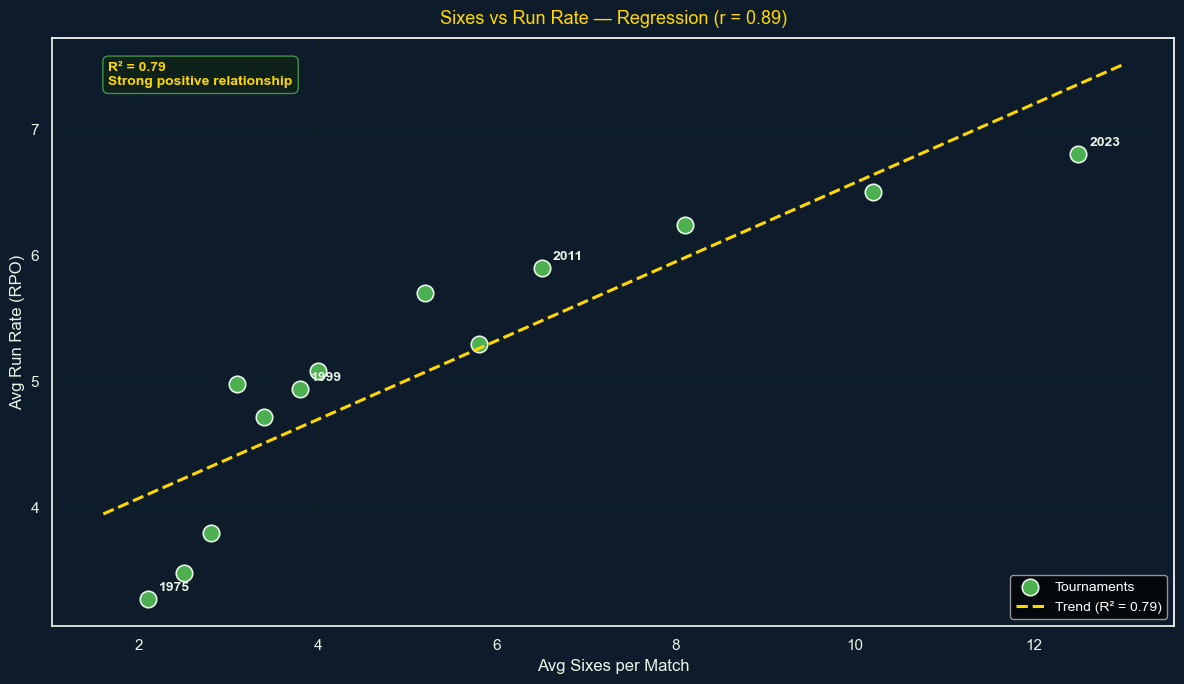

💡 Strong correlation: r = 0.89. More sixes → higher run rate.


In [76]:
fig, ax = plt.subplots(figsize=(12, 7))

# Regression
m2, b2 = np.polyfit(dfb['Avg_6s'], dfb['Avg_RunRate'], 1)
x_fit = np.linspace(dfb['Avg_6s'].min()-0.5, dfb['Avg_6s'].max()+0.5, 200)
y_fit = m2 * x_fit + b2
r2_val, _ = stats.pearsonr(dfb['Avg_6s'], dfb['Avg_RunRate'])

# Scatter
ax.scatter(dfb['Avg_6s'], dfb['Avg_RunRate'],
           color=GREEN, s=140,
           edgecolors=WHITE, linewidths=1.2,
           label="Tournaments")

# Regression line
ax.plot(x_fit, y_fit, '--', color=GOLD, linewidth=2.2,
        label=f'Trend (R² = {r2_val**2:.2f})')

# Important years
important_years = [1975, 1999, 2011, 2023]

for _, row in dfb.iterrows():
    if int(row['Year']) in important_years:
        ax.annotate(str(int(row['Year'])),
                    (row['Avg_6s'], row['Avg_RunRate']),
                    textcoords='offset points', xytext=(8, 6),
                    fontsize=10, color=WHITE, fontweight='bold')

# Insight box
ax.text(0.05, 0.92,
        f'R² = {r2_val**2:.2f}\nStrong positive relationship',
        transform=ax.transAxes,
        fontsize=10, color=GOLD, fontweight='bold',
        bbox=dict(facecolor=SURF, edgecolor=GREEN,
                  boxstyle='round,pad=0.4', alpha=0.8))

# Titles
ax.set_title(f'Sixes vs Run Rate — Regression (r = {r2_val:.2f})',
             fontsize=13, color=GOLD, pad=10)

# ✅ AXIS FIX
ax.set_xlabel('Avg Sixes per Match', color=WHITE)
ax.set_ylabel('Avg Run Rate (RPO)', color=WHITE)

ax.tick_params(axis='x', colors=WHITE)
ax.tick_params(axis='y', colors=WHITE)

ax.spines['bottom'].set_color(WHITE)
ax.spines['left'].set_color(WHITE)

# Grid
ax.grid(alpha=0.2)

# Legend
legend = ax.legend(fontsize=10, frameon=True)
for text in legend.get_texts():
    text.set_color("white")

legend.get_frame().set_facecolor("#000000")
legend.get_frame().set_alpha(0.7)

plt.tight_layout()
plt.savefig('fig7_regression_clean.png', dpi=150,
            bbox_inches='tight', facecolor=BG)

plt.show()

print(f'💡 Strong correlation: r = {r2_val:.2f}. More sixes → higher run rate.')

---
## 📊 Fig 8 — Tournament Scale & Match Margins


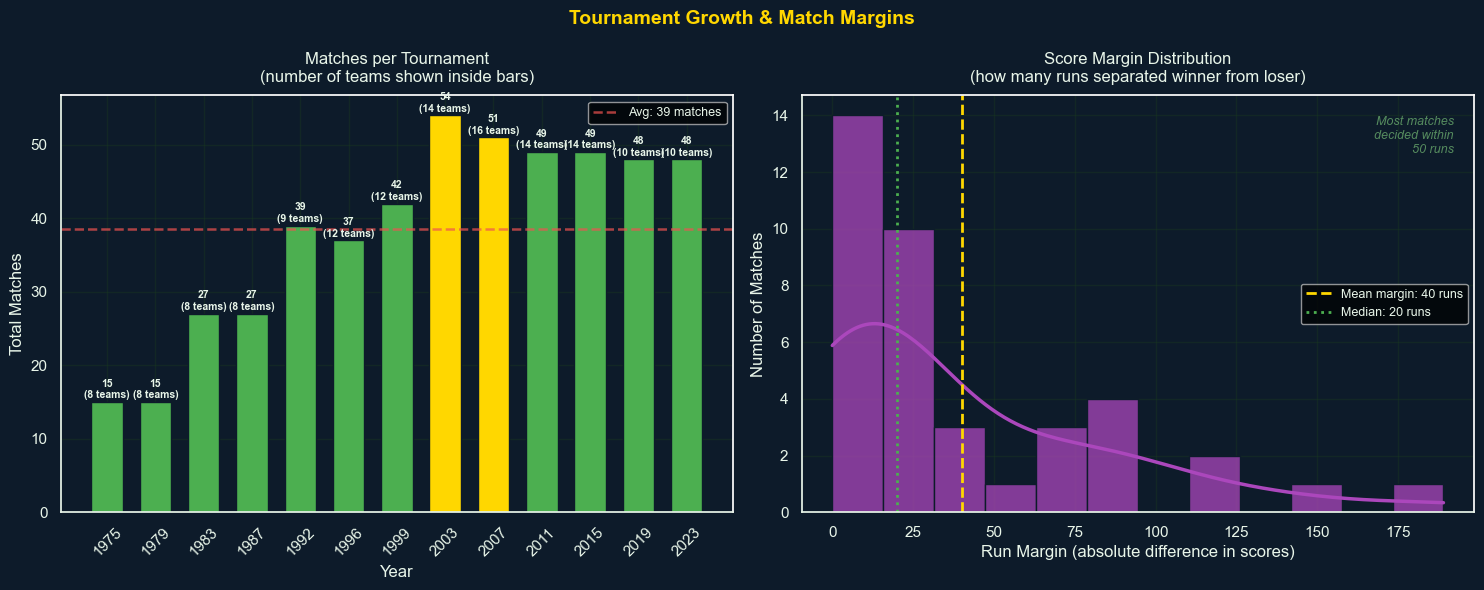

💡 Tournament grew from 15 to 54 matches. Most matches (median) decided by 20 runs.


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Tournament Growth & Match Margins',
             fontsize=14, color=GOLD, fontweight='bold')

# ── Panel A ─────────────────────────────────────
ax = axes[0]

bar_colors2 = [GOLD if m >= 50 else GREEN for m in dfb['Total_Matches']]

bars = ax.bar(dfb['Year'].astype(str), dfb['Total_Matches'],
              color=bar_colors2, edgecolor=BG, width=0.65)

for bar, v, teams in zip(bars, dfb['Total_Matches'], dfb['Total_Teams']):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.5,
            f'{v}\n({teams} teams)',
            ha='center', fontsize=7.5,
            color=WHITE, fontweight='bold')

ax.axhline(dfb['Total_Matches'].mean(),
           color=RED, linestyle='--',
           linewidth=1.8, alpha=0.7,
           label=f"Avg: {dfb['Total_Matches'].mean():.0f} matches")

ax.set_title('Matches per Tournament\n(number of teams shown inside bars)',
             fontsize=12, color=WHITE, pad=10)

# ✅ AXIS FIX
ax.set_xlabel('Year', color=WHITE)
ax.set_ylabel('Total Matches', color=WHITE)

ax.tick_params(axis='x', colors=WHITE, rotation=45)
ax.tick_params(axis='y', colors=WHITE)

ax.spines['bottom'].set_color(WHITE)
ax.spines['left'].set_color(WHITE)

styled_legend(ax, fontsize=9)


# ── Panel B ─────────────────────────────────────
ax2 = axes[1]

margin_data = df['Margin'].dropna()

sns.histplot(margin_data, bins=12, kde=True, ax=ax2,
             color=PURPLE, edgecolor=BG, alpha=0.75,
             line_kws={'linewidth': 2.5, 'color': GOLD})

ax2.axvline(margin_data.mean(), color=GOLD, linestyle='--',
            linewidth=2,
            label=f'Mean margin: {margin_data.mean():.0f} runs')

ax2.axvline(margin_data.median(), color=GREEN, linestyle=':',
            linewidth=2,
            label=f'Median: {margin_data.median():.0f} runs')

ax2.text(0.97, 0.95,
         'Most matches\ndecided within\n50 runs',
         transform=ax2.transAxes,
         fontsize=9, color=MUTED,
         ha='right', va='top', style='italic')

ax2.set_title('Score Margin Distribution\n(how many runs separated winner from loser)',
              fontsize=12, color=WHITE, pad=10)

# ✅ AXIS FIX
ax2.set_xlabel('Run Margin (absolute difference in scores)', color=WHITE)
ax2.set_ylabel('Number of Matches', color=WHITE)

ax2.tick_params(axis='x', colors=WHITE)
ax2.tick_params(axis='y', colors=WHITE)

ax2.spines['bottom'].set_color(WHITE)
ax2.spines['left'].set_color(WHITE)

styled_legend(ax2, fontsize=9)

plt.tight_layout()
plt.savefig('fig8_margins.png', dpi=150,
            bbox_inches='tight', facecolor=BG)

plt.show()

print(f'💡 Tournament grew from 15 to 54 matches. Most matches (median) decided by {df["Margin"].median():.0f} runs.')

---
## 🔮 Fig 9 — 2027 World Cup Prediction


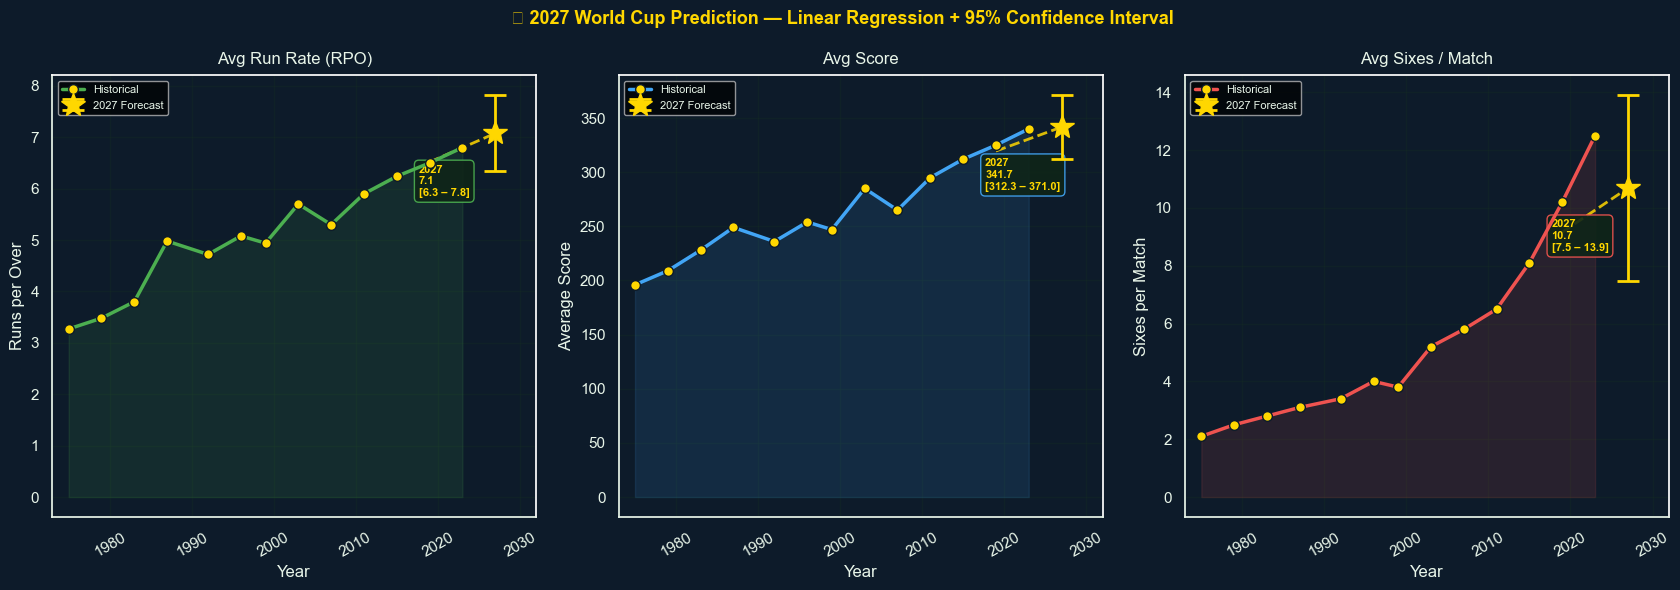


📊 PREDICTED VALUES FOR 2027 WORLD CUP (with 95% CI):
───────────────────────────────────────────────────────
  Avg Run Rate (RPO)     → 7.08  [95% CI: 6.34 – 7.82]
  Avg Score              → 341.67  [95% CI: 312.30 – 371.04]
  Avg Sixes / Match      → 10.68  [95% CI: 7.47 – 13.89]


In [78]:
from scipy import stats as sp_stats

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('🔮 2027 World Cup Prediction — Linear Regression + 95% Confidence Interval',
             fontsize=13, color=GOLD, fontweight='bold')

predict_map = [
    ('Avg Run Rate (RPO)', 'Avg_RunRate', GREEN, axes[0], 'Runs per Over'),
    ('Avg Score',          'Avg_Score',   BLUE,  axes[1], 'Average Score'),
    ('Avg Sixes / Match',  'Avg_6s',      RED,   axes[2], 'Sixes per Match'),
]

for label, col, color, ax, ylabel in predict_map:
    x_data = dfb['Year'].values.astype(float)
    y_vals = dfb[col].values.astype(float)
    n = len(x_data)

    m_p, b_p = np.polyfit(x_data, y_vals, 1)
    pred_2027 = m_p * 2027 + b_p

    # 95% CI calculation
    y_hat = m_p * x_data + b_p
    residuals = y_vals - y_hat
    s_err = np.sqrt(np.sum(residuals**2) / (n - 2))
    x_mean = x_data.mean()

    se_pred = s_err * np.sqrt(1 + 1/n + (2027 - x_mean)**2 /
                             np.sum((x_data - x_mean)**2))

    t_crit = sp_stats.t.ppf(0.975, df=n-2)
    ci_low  = pred_2027 - t_crit * se_pred
    ci_high = pred_2027 + t_crit * se_pred

    # Plot historical
    ax.fill_between(x_data, y_vals, alpha=0.12, color=color)

    ax.plot(x_data, y_vals, color=color, linewidth=2.5,
            marker='o', markersize=7, markerfacecolor=GOLD,
            markeredgecolor=BG, zorder=5, label='Historical')

    # Extrapolation dashed line
    x_ext = np.array([2019, 2023, 2027])
    y_ext = m_p * x_ext + b_p

    ax.plot(x_ext, y_ext, '--', color=GOLD, linewidth=2, alpha=0.85)

    # Prediction with CI
    ax.errorbar([2027], [pred_2027],
                yerr=[[pred_2027-ci_low], [ci_high-pred_2027]],
                fmt='*', color=GOLD, markersize=18,
                capsize=8, capthick=2, elinewidth=2,
                zorder=10, label='2027 Forecast')

    # Label
    ax.annotate(
        f'2027\n{pred_2027:.1f}\n[{ci_low:.1f} – {ci_high:.1f}]',
        (2027, pred_2027),
        textcoords='offset points', xytext=(-55, -45),
        fontsize=8, color=GOLD, fontweight='bold',
        bbox=dict(facecolor=SURF, edgecolor=color,
                  boxstyle='round,pad=0.4', alpha=0.9)
    )

    ax.set_title(label, fontsize=12, color=WHITE, pad=8)

    # ✅ FIXED AXIS VISIBILITY
    ax.set_xlabel('Year', color=WHITE)
    ax.set_ylabel(ylabel, color=WHITE)

    ax.tick_params(axis='x', colors=WHITE, rotation=30)
    ax.tick_params(axis='y', colors=WHITE)

    ax.spines['bottom'].set_color(WHITE)
    ax.spines['left'].set_color(WHITE)

    # Optional grid (clean look)
    ax.grid(alpha=0.2)

    styled_legend(ax, fontsize=8)
    ax.set_xlim(1973, 2032)

plt.tight_layout()
plt.savefig('fig9_prediction.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()


# Print predictions
print('\n📊 PREDICTED VALUES FOR 2027 WORLD CUP (with 95% CI):')
print('─' * 55)

for label, col, _, __, ___ in predict_map:
    x_data = dfb['Year'].values.astype(float)
    y_vals = dfb[col].values.astype(float)
    n = len(x_data)

    m_p, b_p = np.polyfit(x_data, y_vals, 1)
    pred = m_p * 2027 + b_p

    y_hat = m_p * x_data + b_p
    residuals = y_vals - y_hat
    s_err = np.sqrt(np.sum(residuals**2) / (n - 2))
    x_mean = x_data.mean()

    se_pred = s_err * np.sqrt(1 + 1/n + (2027-x_mean)**2 /
                             np.sum((x_data-x_mean)**2))

    t_crit = sp_stats.t.ppf(0.975, df=n-2)

    print(f'  {label:<22} → {pred:.2f}  '
          f'[95% CI: {pred-t_crit*se_pred:.2f} – {pred+t_crit*se_pred:.2f}]')

---
## 🏏 Fig 10 — Team Win Rate Analysis (NEW)


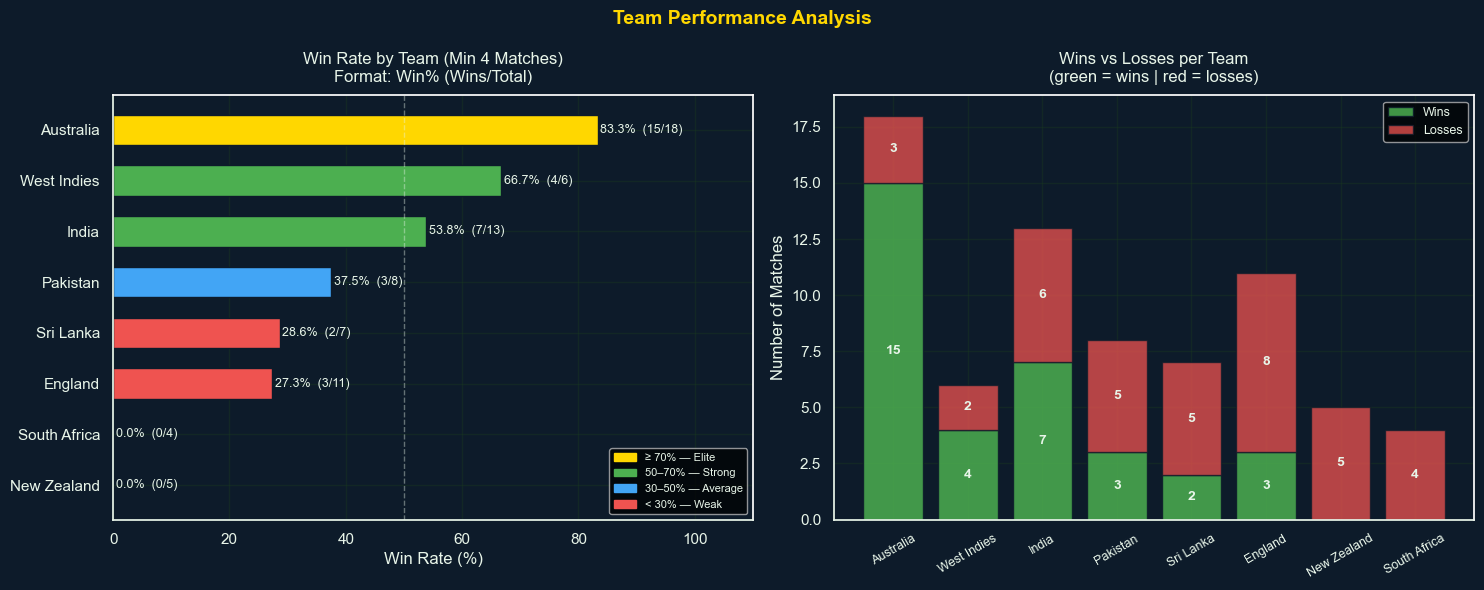

💡 Australia win rate: 83.3%. Only Australia and India (53.8%) are above 50%. South Africa and New Zealand: 0%.


In [79]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Team Performance Analysis', fontsize=14, color=GOLD, fontweight='bold')

# Build win rate data
all_teams = pd.concat([
    df[['Team1','Win_Flag']].rename(columns={'Team1':'Team','Win_Flag':'Won'}),
    df[['Team2']].assign(Won=(df['Winner']==df['Team2']).astype(int))
                .rename(columns={'Team2':'Team'})
])

wr = all_teams.groupby('Team').agg(
    Matches=('Won','count'), Wins=('Won','sum')
).assign(Win_Rate=lambda x: (x['Wins']/x['Matches']*100).round(1))

wr = wr[wr['Matches'] >= 4].sort_values('Win_Rate', ascending=True)

# Color by win rate
wr_colors = [GOLD if r >= 70 else GREEN if r >= 50 else BLUE if r >= 30 else RED
             for r in wr['Win_Rate']]

# ── Panel A: Win Rate Bars ───────────────────────
ax = axes[0]

hbars = ax.barh(wr.index, wr['Win_Rate'],
                color=wr_colors, edgecolor=BG, height=0.6)

ax.axvline(50, color=WHITE, linestyle='--',
           linewidth=1, alpha=0.4, label='50% baseline')

# Win % + values
for bar, val, matches, wins in zip(hbars, wr['Win_Rate'], wr['Matches'], wr['Wins']):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{val}%  ({wins}/{matches})',
            va='center', fontsize=9, color=WHITE)

ax.set_title('Win Rate by Team (Min 4 Matches)\nFormat: Win% (Wins/Total)',
             fontsize=12, color=WHITE, pad=10)

# ✅ Axis fix
ax.set_xlabel('Win Rate (%)', color=WHITE)
ax.tick_params(axis='x', colors=WHITE)
ax.tick_params(axis='y', colors=WHITE)

ax.spines['bottom'].set_color(WHITE)
ax.spines['left'].set_color(WHITE)

ax.set_xlim(0, 110)

# Legend
p1 = mpatches.Patch(color=GOLD, label='≥ 70% — Elite')
p2 = mpatches.Patch(color=GREEN, label='50–70% — Strong')
p3 = mpatches.Patch(color=BLUE, label='30–50% — Average')
p4 = mpatches.Patch(color=RED, label='< 30% — Weak')

styled_legend(ax, handles=[p1, p2, p3, p4], fontsize=8, loc='lower right')


# ── Panel B: Wins vs Losses ─────────────────────
wr2 = wr.sort_values('Win_Rate', ascending=False)

ax2 = axes[1]
losses = wr2['Matches'] - wr2['Wins']
x = np.arange(len(wr2))

b1 = ax2.bar(x, wr2['Wins'], color=GREEN,
             edgecolor=BG, label='Wins', alpha=0.85)

b2 = ax2.bar(x, losses, bottom=wr2['Wins'],
             color=RED, edgecolor=BG,
             label='Losses', alpha=0.75)

# Numbers inside bars
for i, (wins, loss) in enumerate(zip(wr2['Wins'], losses)):
    if wins > 0:
        ax2.text(i, wins/2, str(int(wins)),
                 ha='center', va='center',
                 fontsize=10, color=WHITE, fontweight='bold')
    if loss > 0:
        ax2.text(i, wins + loss/2, str(int(loss)),
                 ha='center', va='center',
                 fontsize=10, color=WHITE, fontweight='bold')

# X-axis team names
ax2.set_xticks(x)
ax2.set_xticklabels(wr2.index, rotation=30,
                    fontsize=9, color=WHITE)

# ✅ Axis fix
ax2.set_ylabel('Number of Matches', color=WHITE)

ax2.tick_params(axis='x', colors=WHITE)
ax2.tick_params(axis='y', colors=WHITE)

ax2.spines['bottom'].set_color(WHITE)
ax2.spines['left'].set_color(WHITE)

ax2.set_title('Wins vs Losses per Team\n(green = wins | red = losses)',
              fontsize=12, color=WHITE, pad=10)

styled_legend(ax2, fontsize=9)

plt.tight_layout()
plt.savefig('fig10_win_rates.png', dpi=150,
            bbox_inches='tight', facecolor=BG)

plt.show()

print('💡 Australia win rate: 83.3%. Only Australia and India (53.8%) are above 50%. South Africa and New Zealand: 0%.')

---
## 📊 Fig 11 — Batting Evolution by Era (NEW)


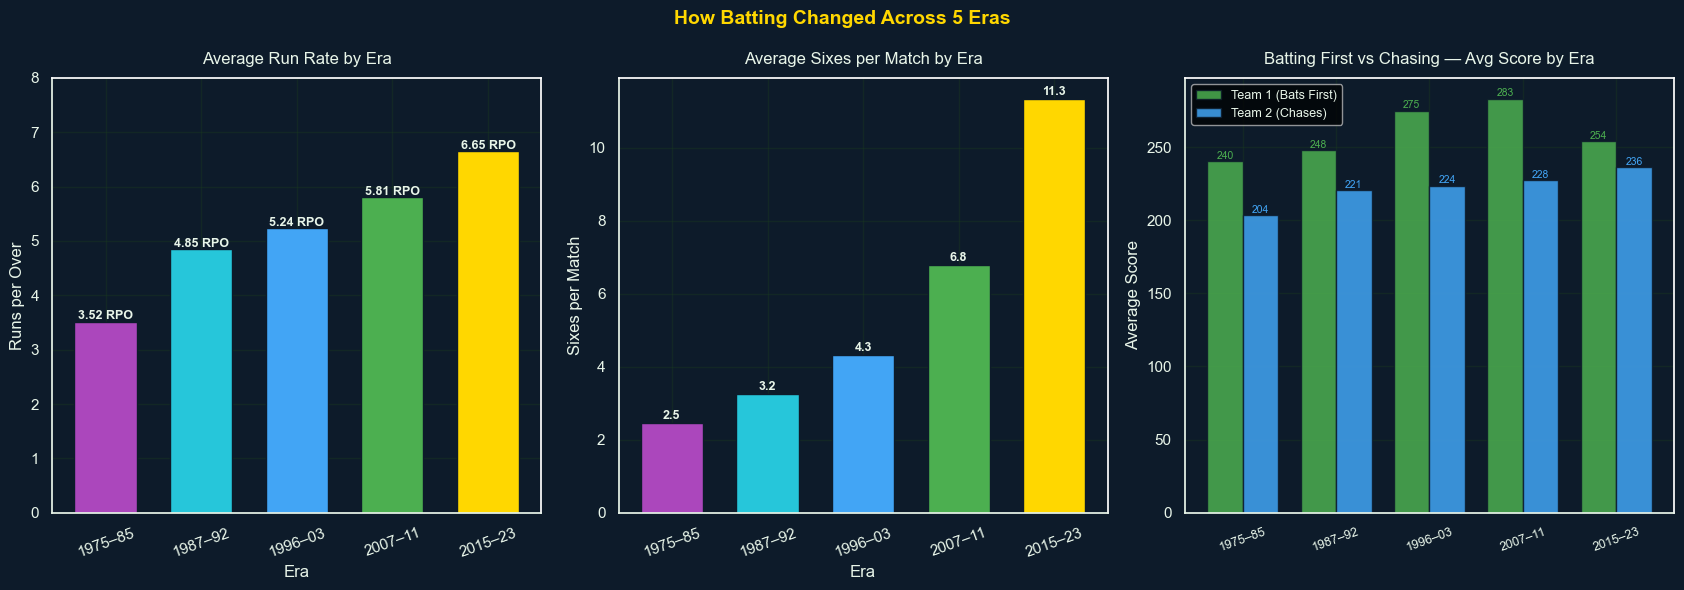

💡 Each era shows clear growth. 2015-23 era sixes nearly double vs 2007-11.
   Teams batting first consistently score higher than chasing teams.


In [80]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('How Batting Changed Across 5 Eras',
             fontsize=14, color=GOLD, fontweight='bold')

era_labels = ['1975–85', '1987–92', '1996–03', '2007–11', '2015–23']
era_colors_list = [PURPLE, TEAL, BLUE, GREEN, GOLD]

# Link match data
df_era = df.merge(dfb[['Year','Avg_RunRate','Avg_6s']], on='Year', how='left')

# ── Panel A ─────────────────────────────────────
era_rr = df_era.groupby('Era', observed=True)['Avg_RunRate'].mean()

bars = axes[0].bar(era_labels, era_rr.values,
                   color=era_colors_list, edgecolor=BG, width=0.65)

for bar, v in zip(bars, era_rr.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.04,
                 f'{v:.2f} RPO', ha='center',
                 fontsize=9, color=WHITE, fontweight='bold')

axes[0].set_title('Average Run Rate by Era', fontsize=12, color=WHITE, pad=10)

# ✅ AXIS FIX
axes[0].set_xlabel('Era', color=WHITE)
axes[0].set_ylabel('Runs per Over', color=WHITE)

axes[0].tick_params(axis='x', colors=WHITE, rotation=20)
axes[0].tick_params(axis='y', colors=WHITE)

axes[0].spines['bottom'].set_color(WHITE)
axes[0].spines['left'].set_color(WHITE)

axes[0].set_ylim(0, 8)


# ── Panel B ─────────────────────────────────────
era_6s = df_era.groupby('Era', observed=True)['Avg_6s'].mean()

bars2 = axes[1].bar(era_labels, era_6s.values,
                    color=era_colors_list, edgecolor=BG, width=0.65)

for bar, v in zip(bars2, era_6s.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{v:.1f}', ha='center',
                 fontsize=9, color=WHITE, fontweight='bold')

axes[1].set_title('Average Sixes per Match by Era',
                  fontsize=12, color=WHITE, pad=10)

# ✅ AXIS FIX
axes[1].set_xlabel('Era', color=WHITE)
axes[1].set_ylabel('Sixes per Match', color=WHITE)

axes[1].tick_params(axis='x', colors=WHITE, rotation=20)
axes[1].tick_params(axis='y', colors=WHITE)

axes[1].spines['bottom'].set_color(WHITE)
axes[1].spines['left'].set_color(WHITE)


# ── Panel C ─────────────────────────────────────
era_t1 = df.groupby('Era', observed=True)['Team1_Score'].mean()
era_t2 = df.groupby('Era', observed=True)['Team2_Score'].mean()

x3 = np.arange(len(era_labels))
w3 = 0.38

bb1 = axes[2].bar(x3 - w3/2, era_t1.values, w3,
                  color=GREEN, edgecolor=BG,
                  label='Team 1 (Bats First)', alpha=0.85)

bb2 = axes[2].bar(x3 + w3/2, era_t2.values, w3,
                  color=BLUE, edgecolor=BG,
                  label='Team 2 (Chases)', alpha=0.85)

for bar in bb1:
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1.5,
                 f'{bar.get_height():.0f}',
                 ha='center', fontsize=7.5, color=GREEN)

for bar in bb2:
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1.5,
                 f'{bar.get_height():.0f}',
                 ha='center', fontsize=7.5, color=BLUE)

axes[2].set_xticks(x3)
axes[2].set_xticklabels(era_labels,
                        rotation=20,
                        fontsize=9,
                        color=WHITE)

axes[2].set_title('Batting First vs Chasing — Avg Score by Era',
                  fontsize=12, color=WHITE, pad=10)

# ✅ AXIS FIX
axes[2].set_ylabel('Average Score', color=WHITE)

axes[2].tick_params(axis='x', colors=WHITE)
axes[2].tick_params(axis='y', colors=WHITE)

axes[2].spines['bottom'].set_color(WHITE)
axes[2].spines['left'].set_color(WHITE)

styled_legend(axes[2], fontsize=9)

plt.tight_layout()
plt.savefig('fig11_era_evolution.png', dpi=150,
            bbox_inches='tight', facecolor=BG)

plt.show()

print('💡 Each era shows clear growth. 2015-23 era sixes nearly double vs 2007-11.')
print('   Teams batting first consistently score higher than chasing teams.')

---
## 🌍 Fig 12 — Tournament Format & Host Analysis (NEW)


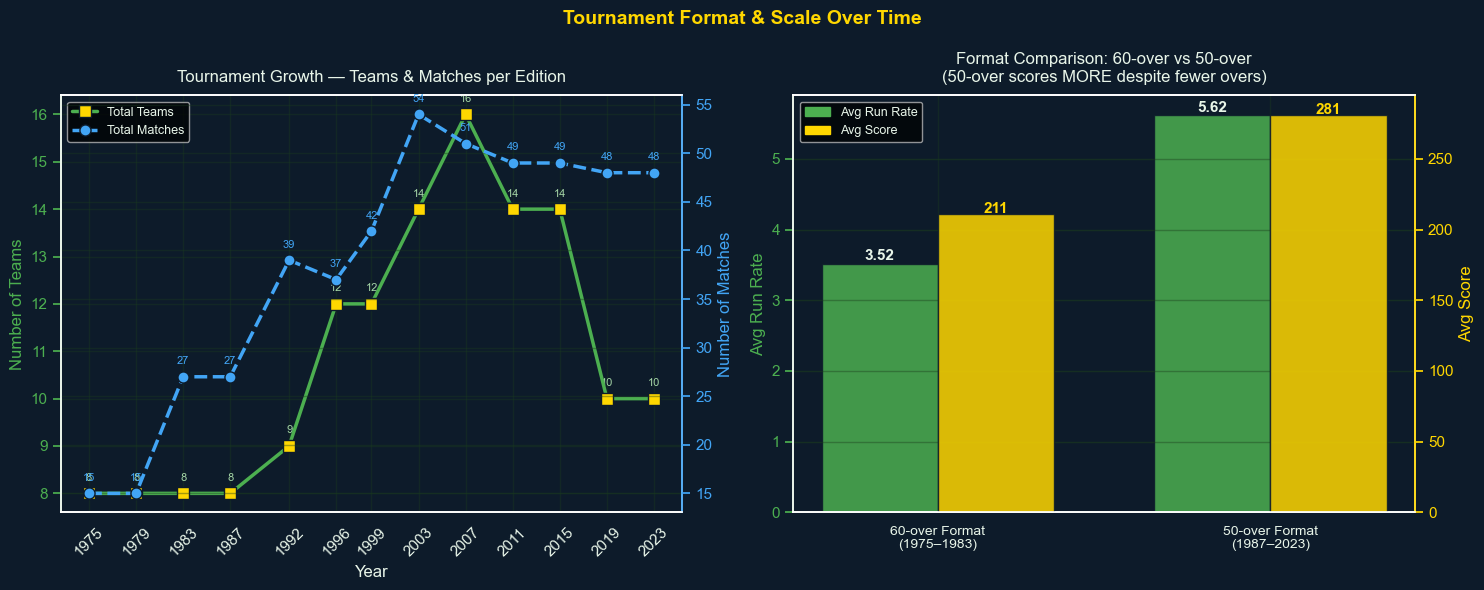

💡 50-over format has higher run rates than 60-over, because batting evolved — not because there are more overs.
   60-over avg RPO: 3.52  |  50-over avg RPO: 5.62


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Tournament Format & Scale Over Time',
             fontsize=14, color=GOLD, fontweight='bold')

# ── Panel A: Teams & Matches growth ──────────────
ax = axes[0]
ax2_twin = ax.twinx()

l1 = ax.plot(dfb['Year'], dfb['Total_Teams'], color=GREEN, linewidth=2.5,
             marker='s', markersize=8, markerfacecolor=GOLD,
             markeredgecolor=BG, label='Total Teams', zorder=5)

l2 = ax2_twin.plot(dfb['Year'], dfb['Total_Matches'], color=BLUE, linewidth=2.5,
                   marker='o', markersize=8, markerfacecolor=BLUE,
                   markeredgecolor=BG, linestyle='--',
                   label='Total Matches', zorder=5)

# Labels
for x, y in zip(dfb['Year'], dfb['Total_Teams']):
    ax.annotate(str(y), (x, y), textcoords='offset points',
                xytext=(0, 9), fontsize=8, color=LIME, ha='center')

for x, y in zip(dfb['Year'], dfb['Total_Matches']):
    ax2_twin.annotate(str(y), (x, y), textcoords='offset points',
                      xytext=(0, 9), fontsize=8, color=BLUE, ha='center')

ax.set_title('Tournament Growth — Teams & Matches per Edition',
             fontsize=12, color=WHITE, pad=10)

# ✅ AXIS FIX (Panel A)
ax.set_xlabel('Year', color=WHITE)
ax.set_ylabel('Number of Teams', color=GREEN)
ax2_twin.set_ylabel('Number of Matches', color=BLUE)

ax.tick_params(axis='x', colors=WHITE, rotation=45)
ax.tick_params(axis='y', colors=GREEN)
ax2_twin.tick_params(axis='y', colors=BLUE)

ax.spines['bottom'].set_color(WHITE)
ax.spines['left'].set_color(GREEN)
ax2_twin.spines['right'].set_color(BLUE)

ax.set_xticks(dfb['Year'])

# Legend
lines = l1 + l2
labels = [l.get_label() for l in lines]

leg = ax.legend(lines, labels, fontsize=9, loc='upper left', frameon=True)
for t in leg.get_texts():
    t.set_color(WHITE)

leg.get_frame().set_facecolor('#000000')
leg.get_frame().set_alpha(0.7)


# ── Panel B: Format (60-over vs 50-over) ─────────
ax3 = axes[1]
format_rr = dfb.groupby('Format')['Avg_RunRate'].mean()
format_sc = dfb.groupby('Format')['Avg_Score'].mean()

formats = ['60-over', '50-over']
rr_vals = [format_rr.get(f, 0) for f in formats]
sc_vals = [format_sc.get(f, 0) for f in formats]

x4 = np.arange(2)
w4 = 0.35

bb3 = ax3.bar(x4 - w4/2, rr_vals, w4, color=GREEN,
              edgecolor=BG, label='Avg Run Rate', alpha=0.85)

ax3_twin = ax3.twinx()

bb4 = ax3_twin.bar(x4 + w4/2, sc_vals, w4, color=GOLD,
                   edgecolor=BG, label='Avg Score', alpha=0.85)

# Labels
for bar, v in zip(bb3, rr_vals):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             f'{v:.2f}', ha='center', fontsize=11,
             color=WHITE, fontweight='bold')

for bar, v in zip(bb4, sc_vals):
    ax3_twin.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                  f'{v:.0f}', ha='center', fontsize=11,
                  color=GOLD, fontweight='bold')

ax3.set_xticks(x4)
ax3.set_xticklabels(['60-over Format\n(1975–1983)',
                     '50-over Format\n(1987–2023)'],
                     fontsize=10, color=WHITE)

# ✅ AXIS FIX (Panel B)
ax3.set_title('Format Comparison: 60-over vs 50-over\n(50-over scores MORE despite fewer overs)',
              fontsize=12, color=WHITE, pad=10)

ax3.set_ylabel('Avg Run Rate', color=GREEN)
ax3_twin.set_ylabel('Avg Score', color=GOLD)

ax3.tick_params(axis='x', colors=WHITE)
ax3.tick_params(axis='y', colors=GREEN)
ax3_twin.tick_params(axis='y', colors=GOLD)

ax3.spines['bottom'].set_color(WHITE)
ax3.spines['left'].set_color(GREEN)
ax3_twin.spines['right'].set_color(GOLD)

# Legend
p_g = mpatches.Patch(color=GREEN, label='Avg Run Rate')
p_go = mpatches.Patch(color=GOLD, label='Avg Score')

leg2 = ax3.legend(handles=[p_g, p_go], fontsize=9,
                  loc='upper left', frameon=True)

for t in leg2.get_texts():
    t.set_color(WHITE)

leg2.get_frame().set_facecolor('#000000')
leg2.get_frame().set_alpha(0.7)

plt.tight_layout()
plt.savefig('fig12_format.png', dpi=150,
            bbox_inches='tight', facecolor=BG)

plt.show()

print('💡 50-over format has higher run rates than 60-over, because batting evolved — not because there are more overs.')
print(f'   60-over avg RPO: {rr_vals[0]:.2f}  |  50-over avg RPO: {rr_vals[1]:.2f}')